# Sesión 1 — Carga y unión de tablas




In [179]:
import pandas as pd
import matplotlib.pyplot as plt


df_customers = pd.read_csv("https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto2_Dashboard%20de%20Indicadores%20Comerciales/olist_customers_dataset.csv")
df_order_items = pd.read_csv("https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto2_Dashboard%20de%20Indicadores%20Comerciales/olist_order_items_dataset.csv")
df_order_payments = pd.read_csv("https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto2_Dashboard%20de%20Indicadores%20Comerciales/olist_order_payments_dataset.csv")
df_order_reviews = pd.read_csv("https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto2_Dashboard%20de%20Indicadores%20Comerciales/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto2_Dashboard%20de%20Indicadores%20Comerciales/olist_orders_dataset.csv")
df_products = pd.read_csv("https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto2_Dashboard%20de%20Indicadores%20Comerciales/olist_products_dataset.csv")
df_sellers = pd.read_csv("https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto2_Dashboard%20de%20Indicadores%20Comerciales/olist_sellers_dataset.csv")
df_category_translation = pd.read_csv("https://raw.githubusercontent.com/vicenteyanezreinoso01-spec/Proyecto-datos-an-lisis/refs/heads/main/Proyecto2_Dashboard%20de%20Indicadores%20Comerciales/product_category_name_translation.csv")

In [180]:
# df_orders + df_customers + df_order_items + df_order_payments + df_products + df_sellers + df_order_reviews + df_category_translation

df_merged = pd.merge(df_orders, df_customers, on="customer_id", how="left")

df_merged = pd.merge(df_merged, df_order_items, on="order_id", how="left")

df_merged = pd.merge(df_merged, df_order_payments, on="order_id", how="left")

df_merged = pd.merge(df_merged, df_products, on="product_id", how="left")

df_merged = pd.merge(df_merged, df_sellers, on="seller_id", how="left")

df_merged = pd.merge(df_merged, df_order_reviews, on="order_id", how="left")

df_merged = pd.merge(df_merged, df_category_translation, on="product_category_name", how="left")

df_merged.shape


(119143, 40)

In [181]:
resumen_nulos = pd.DataFrame({
    "total_valores": len(df_merged),
    "valores_nulos": df_merged.isnull().sum(),
    "porcentaje_nulos": (df_merged.isnull().sum() / len(df_merged) * 100).round(2)})
resumen_nulos

,total_valores,valores_nulos,porcentaje_nulos
order_id,119143,0,0.00
customer_id,119143,0,0.00
order_status,119143,0,0.00
order_purchase_timestamp,119143,0,0.00
order_approved_at,119143,177,0.15
order_delivered_carrier_date,119143,2086,1.75
order_delivered_customer_date,119143,3421,2.87
order_estimated_delivery_date,119143,0,0.00
customer_unique_id,119143,0,0.00
customer_zip_code_prefix,119143,0,0.00


In [182]:
#Eliminaremos las 3 filas de payment ya que son insignificantes
df_merged = df_merged[df_merged["payment_sequential"].notnull()]
df_merged.shape

(119140, 40)

In [183]:
# Rellenamos categorías de producto faltantes (español e inglés) con "Sin categoría"
df_merged["product_category_name"] = df_merged["product_category_name"].fillna("Sin categoría")
df_merged["product_category_name_english"] = df_merged["product_category_name_english"].fillna("Sin categoría")

In [184]:
# Rellenamos comentarios de review faltantes con "Sin comentario"
df_merged["review_comment_title"] = df_merged["review_comment_title"].fillna("Sin comentario")
df_merged["review_comment_message"] = df_merged["review_comment_message"].fillna("Sin comentario")

df_merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,Sin comentario,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,Sin comentario,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,Sin comentario,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,31570.0,belo horizonte,SP,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,14840.0,guariba,SP,e73b67b67587f7644d5bd1a52deb1b01,5.0,Sin comentario,Sin comentario,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [185]:
resumen_nulos = pd.DataFrame({
    "total_valores": len(df_merged),
    "valores_nulos": df_merged.isnull().sum(),
    "porcentaje_nulos": (df_merged.isnull().sum() / len(df_merged) * 100).round(2)})
resumen_nulos

,total_valores,valores_nulos,porcentaje_nulos
order_id,119140,0,0.00
customer_id,119140,0,0.00
order_status,119140,0,0.00
order_purchase_timestamp,119140,0,0.00
order_approved_at,119140,177,0.15
order_delivered_carrier_date,119140,2086,1.75
order_delivered_customer_date,119140,3421,2.87
order_estimated_delivery_date,119140,0,0.00
customer_unique_id,119140,0,0.00
customer_zip_code_prefix,119140,0,0.00


In [186]:
columnas_fecha = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in columnas_fecha:
    df_merged[col] = pd.to_datetime(df_merged[col])

    df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119140 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119140 non-null  object        
 1   customer_id                    119140 non-null  object        
 2   order_status                   119140 non-null  object        
 3   order_purchase_timestamp       119140 non-null  datetime64[ns]
 4   order_approved_at              118963 non-null  object        
 5   order_delivered_carrier_date   117054 non-null  object        
 6   order_delivered_customer_date  115719 non-null  object        
 7   order_estimated_delivery_date  119140 non-null  object        
 8   customer_unique_id             119140 non-null  object        
 9   customer_zip_code_prefix       119140 non-null  int64         
 10  customer_city                  119140 non-null  object        
 11  custo

# Sesión 2: KPIs de negocio

In [187]:
# KPIs 0 MENSUALES

df_merged["mes_venta"] = df_merged["order_purchase_timestamp"].dt.to_period("M")

ventas_mensuales = df_merged.groupby("mes_venta")["payment_value"].sum()
ventas_mensuales

,payment_value
mes_venta,
2016-09,388.47
2016-10,76559.05
2016-12,19.62
2017-01,190806.27
2017-02,351848.13
2017-03,547769.84
2017-04,512126.52
2017-05,737425.31
2017-06,613777.41


In [188]:
# KPIs 1 VENTAS ANUALES
df_merged["anio_venta"] = df_merged["order_purchase_timestamp"].dt.to_period("Y")

ventas_anuales = df_merged.groupby("anio_venta")["payment_value"].sum()
ventas_anuales

,payment_value
anio_venta,
2016,76967.14
2017,9334920.90
2018,11167775.97


In [189]:
# KPIs 2 TICKET PROMEDIO GLOBAL
ticket_promedio = df_merged["payment_value"].mean()
ticket_promedio

np.float64(172.73513521906997)

In [190]:
# KPIs 3 TOP 10 CATEGORÍAS POR INGRESOS
suma_por_categoria = df_merged.groupby("product_category_name_english")["payment_value"].sum()

top_10_categorias = suma_por_categoria.sort_values(ascending=False).head(10)
print(top_10_categorias)

product_category_name_english
bed_bath_table           1743998.80
health_beauty            1662963.59
computers_accessories    1599481.06
furniture_decor          1443963.61
watches_gifts            1430553.48
sports_leisure           1400223.07
housewares               1097900.09
auto                      855095.68
garden_tools              840721.59
cool_stuff                781933.97
Name: payment_value, dtype: float64


In [191]:
# KPIs 4 VENTAS POR ESTADO DEL CLIENTE
ventas_por_estado = df_merged.groupby("customer_state")["payment_value"].sum()

top_estados = ventas_por_estado.sort_values(ascending=False).head(10)
print(top_estados)

customer_state
SP    7726078.35
RJ    2795615.67
MG    2351221.09
RS    1160175.66
PR    1079795.49
BA     805070.98
SC     801276.45
GO     520481.65
DF     438095.32
ES     408611.64
Name: payment_value, dtype: float64


In [192]:
#  KPIs 5 USO DE CADA MÉTODO DE PAGO
conteo_por_metodo = df_merged.groupby("payment_type")["payment_type"].count()
pct_por_metodo = (conteo_por_metodo / len(df_merged)) * 100
pct_por_metodo

,payment_type
payment_type,
boleto,19.464496
credit_card,73.674668
debit_card,1.431929
not_defined,0.002518
voucher,5.426389


In [193]:
# KPIs 6 PROMDIO DE CUOTAS

cuotas_promedio = df_merged["payment_installments"].mean()
cuotas_promedio.round(2)

np.float64(2.94)

In [194]:
# KPI 7: clientes únicos vs. pedidos totales
clientes_unicos = df_merged["customer_unique_id"].unique()
pedidos_totales = df_merged["order_id"].unique()

tabla_clientes_vs_pedidos = pd.DataFrame({
    "clientes_unicos": [len(clientes_unicos)],
    "pedidos_totales": [len(pedidos_totales)],
    "relacion_clientes_vs_pedidos": [len(clientes_unicos) / len(pedidos_totales)]
})

tabla_clientes_vs_pedidos

,clientes_unicos,pedidos_totales,relacion_clientes_vs_pedidos
0,96095,99440,0.966362


In [195]:
# KPI 8, PROMEDIO DE RESEÑAS GLOBAL
promedio_resenas_global = df_merged["review_score"].mean()
promedio_resenas_global.round(2)

np.float64(4.02)

In [196]:
# KPI 9, PROMEDIO DE RESEÑAS POR CATEGORÍAS
promedio_por_categoria = df_merged.groupby("product_category_name_english")["review_score"].mean()
promedio_por_categoria.round(2)

,review_score
product_category_name_english,
Sin categoría,3.16
agro_industry_and_commerce,4.15
air_conditioning,3.97
art,3.94
arts_and_craftmanship,4.12
...,...
stationery,4.19
tablets_printing_image,4.12
telephony,3.95


In [230]:
# KPIs 10, % de pedidos con score bajo (1-2) vs. alto (4-5)
porcentaje_bajo = (df_merged["review_score"] >= 1) & (df_merged["review_score"] <= 2)
porcentaje_alto = (df_merged["review_score"] >= 4) & (df_merged["review_score"] <= 5)
porcentaje_neutro = (df_merged["review_score"] == 3).mean() * 100

porcentaje_bajo = porcentaje_bajo.mean() * 100
porcentaje_alto = porcentaje_alto.mean() * 100
porcentaje_neutro = porcentaje_neutro.mean() * 100


dff = pd.DataFrame({
    "porcentaje_bajo": [porcentaje_bajo],
    "porcentaje_neutro": [porcentaje_neutro],
    "porcentaje_alto": [porcentaje_alto]
})
dff

,porcentaje_bajo,porcentaje_neutro,porcentaje_alto
0,16.440322,830.45157,74.418331


In [198]:
# KPI 11: TIEMPO PROMEDIO DE ENTREGA EN DÍAS
diferencia_entrega = (df_merged["order_delivered_customer_date"] - df_merged["order_purchase_timestamp"])
dia_promedio_entrega = diferencia_entrega.dt.days.mean()
print("Promedio de entrega", dia_promedio_entrega.round(3), "días")

Promedio de entrega 12.022 días


In [254]:
#KPIs 12, % de pedidos entregados después de la fecha estimada.

porcentaje_atrasado = (df_merged["order_delivered_customer_date"] > df_merged["order_estimated_delivery_date"]).mean() * 100
print("Porcentaje atrasado", porcentaje_atrasado)

print("")

#KPIs 12, % de pedidos entregados después de la fecha estimada.

porcentaje_atiempo = (df_merged["order_delivered_customer_date"] <= df_merged["order_estimated_delivery_date"]).mean() * 100
print("Porcentaje a tiempo", porcentaje_atiempo)

print("")

#PEDIDOS SIN INFORMACION DE ENTREGA
porcentaje_sin_informacion = (df_merged["order_delivered_customer_date"].isnull()).mean() * 100
print("Porcentaje sin informacion", porcentaje_sin_informacion)

print("")

print("Suma de 3 componentes (debe ser 100 =)",porcentaje_atrasado + porcentaje_atiempo + porcentaje_sin_informacion)


Porcentaje atrasado 7.608695652173914

Porcentaje a tiempo 89.51989256337083

Porcentaje sin informacion 2.8714117844552627

Suma de 3 componentes (debe ser 100 =) 100.0


# Sesión 3 Storytelling visual

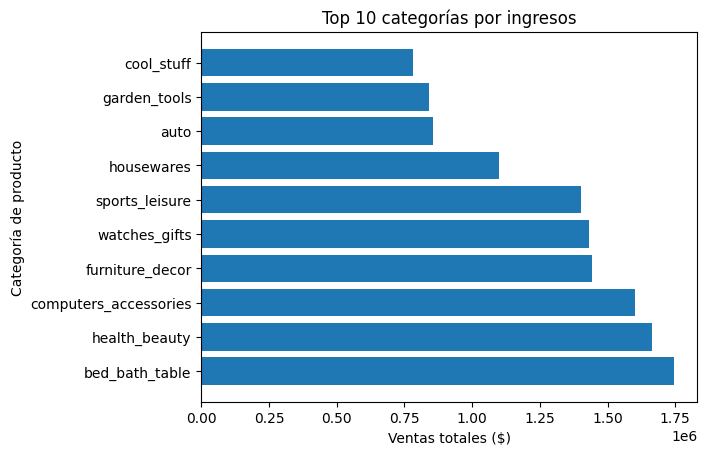

In [200]:
#GRÁFICO DE INGRESOS POR CATEGORÍA
plt.barh(top_10_categorias.index, top_10_categorias.values)
plt.xlabel("Ventas totales ($)")
plt.ylabel("Categoría de producto")
plt.title("Top 10 categorías por ingresos")
plt.show()

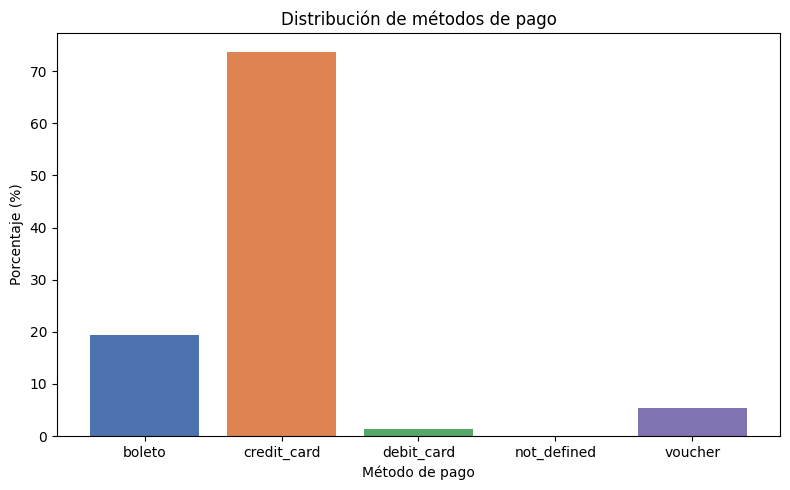

In [205]:
# % métodos de pago
plt.figure(figsize=(8, 5))
plt.bar(pct_por_metodo.index, pct_por_metodo.values, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])

plt.xlabel("Método de pago")
plt.ylabel("Porcentaje (%)")
plt.title("Distribución de métodos de pago")

plt.tight_layout()
plt.show()

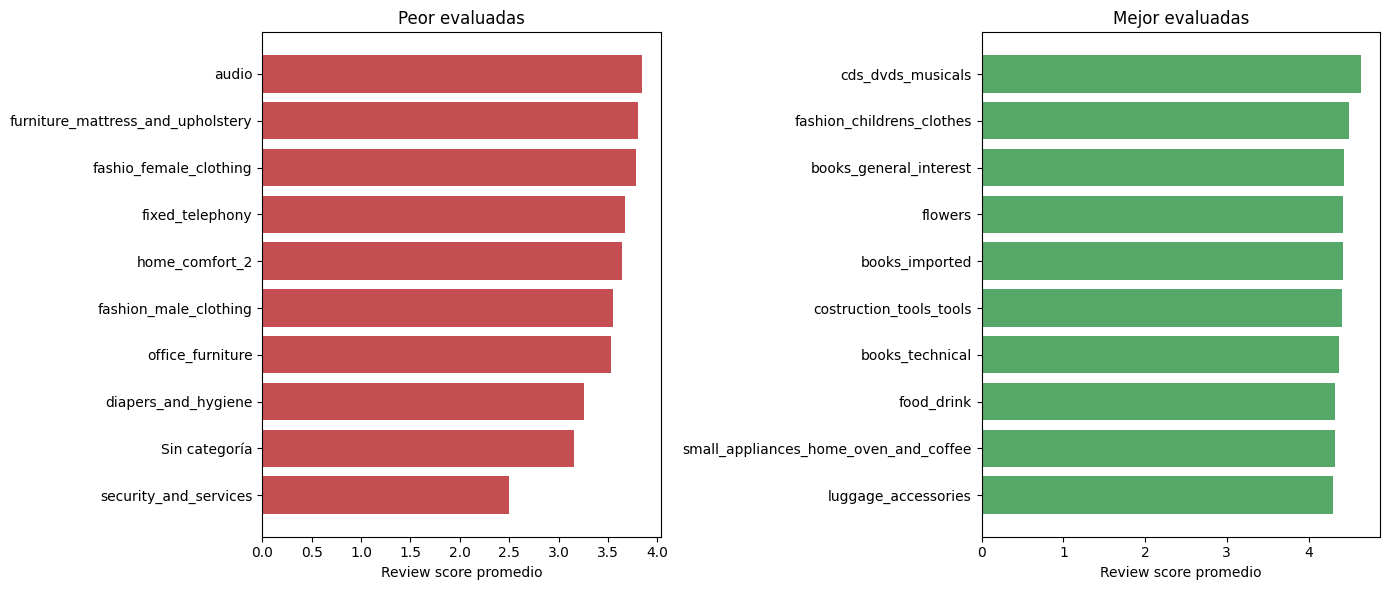

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(peor_10.index, peor_10.values, color="#C44E52")
axes[0].set_title("Peor evaluadas")
axes[0].set_xlabel("Review score promedio")

axes[1].barh(mejor_10.index, mejor_10.values, color="#55A868")
axes[1].set_title("Mejor evaluadas")
axes[1].set_xlabel("Review score promedio")

plt.tight_layout()
plt.show()

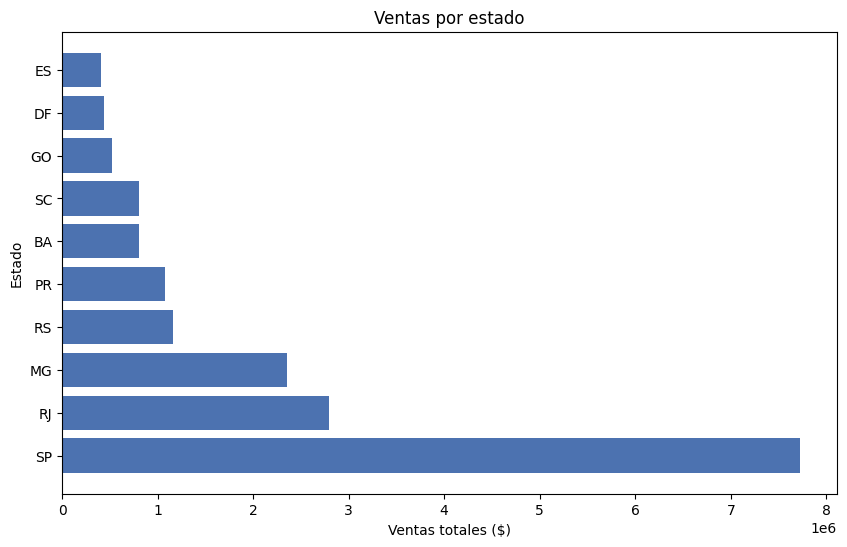

In [221]:
plt.figure(figsize=(10, 6))
plt.barh(top_estados.index, top_estados.values, color="#4C72B0")
plt.xlabel("Ventas totales ($)")
plt.ylabel("Estado")
plt.title("Ventas por estado")
plt.show()

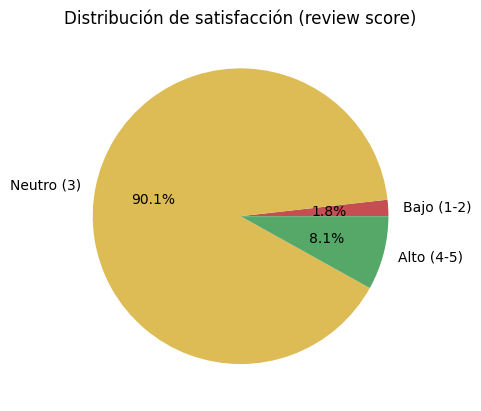

In [235]:

valores = [porcentaje_bajo, porcentaje_neutro, porcentaje_alto]
etiquetas = ["Bajo (1-2)", "Neutro (3)", "Alto (4-5)"]
colores = ["#C44E52", "#DDBB55", "#55A868"]

plt.pie(valores, labels=etiquetas, autopct="%1.1f%%", colors=colores)
plt.title("Distribución de satisfacción (review score)")
plt.show()

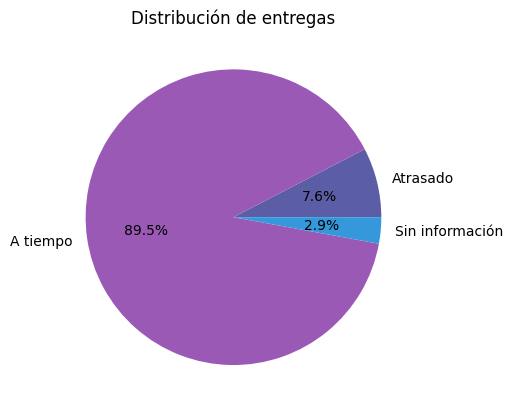

In [261]:
# Porcentaje de pedidos realizados atrasados, a tiempo y sin información
valores = [porcentaje_atrasado, porcentaje_atiempo, porcentaje_sin_informacion]
etiquetas = ["Atrasado", "A tiempo", "Sin información"]
colores = ["#5B5EA6", "#9B59B6", "#3498DB"]
plt.pie(valores, labels=etiquetas, autopct="%1.1f%%", colors=colores)
plt.title("Distribución de entregas")
plt.show()



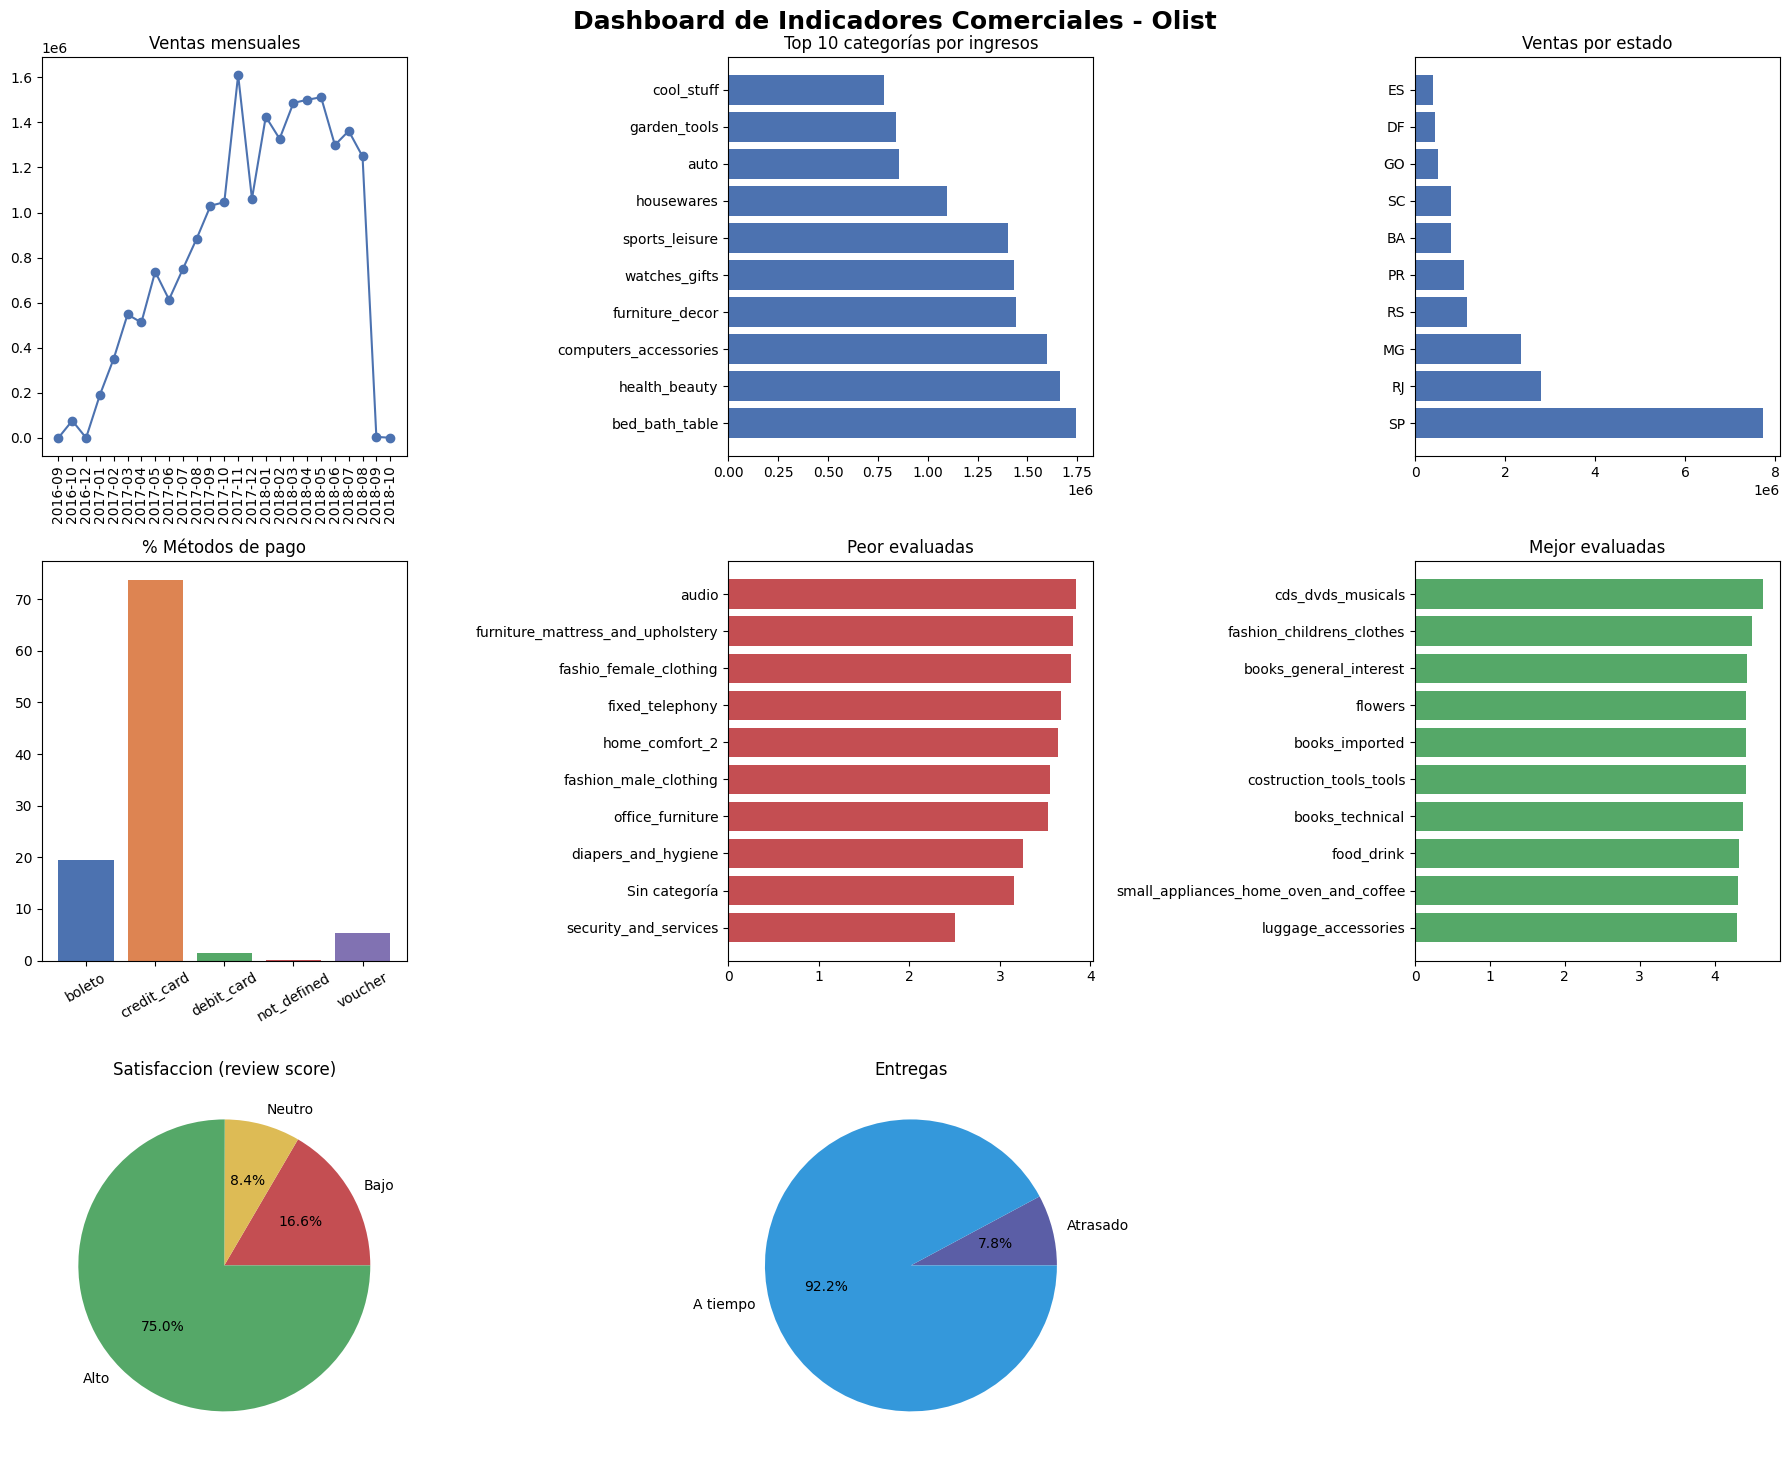

Text(0.5, 0.98, 'Dashboard de Indicadores Comerciales - Olist')

<Figure size 640x480 with 0 Axes>

In [269]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# (0,0) Ventas mensuales
axes[0,0].plot(ventas_mensuales.index.astype(str), ventas_mensuales.values, marker="o", color="#4C72B0")
axes[0,0].set_title("Ventas mensuales")
axes[0,0].tick_params(axis="x", rotation=90)

# (0,1) Top 10 categorías
axes[0,1].barh(top_10_categorias.index, top_10_categorias.values, color="#4C72B0")
axes[0,1].set_title("Top 10 categorías por ingresos")

# (0,2) Ventas por estado
axes[0,2].barh(top_estados.index, top_estados.values, color="#4C72B0")
axes[0,2].set_title("Ventas por estado")

# (1,0) % métodos de pago
axes[1,0].bar(pct_por_metodo.index, pct_por_metodo.values,
              color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])
axes[1,0].set_title("% Métodos de pago")
axes[1,0].tick_params(axis="x", rotation=30)

# (1,1) Peor 10 categorías (review score)
axes[1,1].barh(peor_10.index, peor_10.values, color="#C44E52")
axes[1,1].set_title("Peor evaluadas")

# (1,2) Mejor 10 categorías (review score)
axes[1,2].barh(mejor_10.index, mejor_10.values, color="#55A868")
axes[1,2].set_title("Mejor evaluadas")

# (2,0) Torta satisfacción
axes[2,0].pie([porcentaje_bajo, porcentaje_neutro, porcentaje_alto],
              labels=["Bajo", "Neutro", "Alto"], autopct="%1.1f%%",
              colors=["#C44E52", "#DDBB55", "#55A868"])
axes[2,0].set_title("Satisfaccion (review score)")

# (2,1) Torta entregas
axes[2,1].pie([porcentaje_atrasado, porcentaje_atiempo],
              labels=["Atrasado", "A tiempo"], autopct="%1.1f%%",
              colors=["#5B5EA6", "#3498DB"])
axes[2,1].set_title("Entregas")

# (2,2) Celda vacia, la ocultamos
axes[2,2].axis("off")

plt.suptitle("Dashboard de Indicadores Comerciales - Olist", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()
plt.suptitle("Dashboard de Indicadores Comerciales - Olist", fontsize=18, fontweight="bold")

Conclusiones de negocio — Dashboard Olist
1. El negocio está concentrado geográficamente
São Paulo (SP) genera casi 3 veces más ventas que el segundo estado (RJ). Esto no es necesariamente malo, pero significa que el negocio depende mucho de una sola región — si algo afecta a SP (logística, competencia local), impacta fuerte en el total.

2. La tarjeta de crédito domina como forma de pago
74% de las transacciones son con tarjeta de crédito. Vale la pena preguntarse si conviene ofrecer mejores condiciones en boleto o débito para diversificar, o si está bien así porque el cliente ya está cómodo pagando de esa forma.

3. La satisfacción general es buena, pero no pareja
El promedio de reseñas es alto (75% de los pedidos con nota 4-5), pero hay categorías específicas (como "audio" o "furniture_mattress_and_upholstery") con notas bajas consistentes — ahí hay una oportunidad concreta: revisar calidad de esos productos o del proceso de entrega asociado a ellos.

4. La logística funciona bien en general, con margen de mejora
92% de los pedidos llegan a tiempo. El 8% que llega atrasado no es crítico, pero es el tipo de número que vale la pena monitorear en el tiempo — si sube, es señal de un problema operativo creciente.

5. Baja tasa de recompra
De 99,440 pedidos, solo 96,095 son de clientes distintos — la mayoría de los clientes compra una sola vez. Para un negocio de e-commerce, esto suele ser un foco de mejora importante (fidelización), porque conseguir un cliente nuevo cuesta más que retener uno existente.